In [1]:
import os
import importlib
import sys

# for math operations
import numpy as np
import scipy

# for plotting
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# for accelerated computing
import jax
import jax.numpy as jnp
import torch

# Python reachability toolbox
import hj_reachability as hj

# QP tools
import osqp
from scipy import sparse

In [2]:
# Load dynamics
import dubins_model
importlib.reload(dubins_model)
from dubins_model import Dubins3D

dubins = Dubins3D()

In [31]:
# Load learned value function

import latent_dubin_ca_value
importlib.reload(latent_dubin_ca_value)
from latent_dubin_ca_value import latent_dubin_ca_value
value_func = latent_dubin_ca_value()

/home/arun/PhD_Five/EAIS/.conda/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}
Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
decoder
Optimizer model_opt has 27133189 variables.


/home/arun/PhD_Five/EAIS/latent-affine-safety/eais_hw2/dreamerv3-torch/tools.py:904: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


DDPG under the Avoid annealed Bellman equation with no Disturbance has been loaded!


100%|##########|  2.8000/2.799999952316284 [00:00<00:00,  8.41sim_s/s]


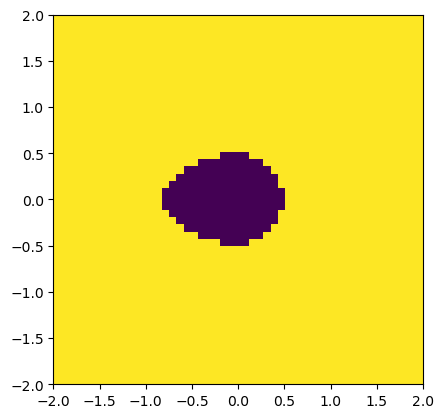

In [18]:
sys.path.append('./value_functions')
import hj_value_function
importlib.reload(hj_value_function)
from hj_value_function import HJValueFunction

ground_truth_value_func = HJValueFunction(dubins)

# Define failure set
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - ground_truth_value_func.grid.states[..., :2], axis=-1) - value_func.param['radius']
failure_lx = obstacle1

ground_truth_value_func.compute_V(failure_lx)

plt.imshow(ground_truth_value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])

[0.63500184]
[0.57558405]
[0.36675704]
[0.03684533]
[0.38226786]
[-0.01550871]
[0.7146165]
[0.24061775]
[-0.35730666]
[0.55327344]
[0.09765369]
[-0.31130582]
[0.3397937]
[0.2667603]
[0.08128399]
[-0.29359275]
[0.06772846]
[0.16437829]
[0.22192752]
[0.3156531]
[0.44685873]
[0.5268542]
[0.7327697]
[0.7996144]
[0.8510906]
[0.8974441]
[0.9019156]
[0.91418725]
[0.91915435]
[0.9261607]
[0.9298533]
[0.9282725]
[0.9260051]
[0.91249007]
[0.9030603]
[0.88675976]
[0.8446186]
[0.81481355]
[0.7993483]
[0.7983754]
[0.61556125]
[0.51365703]
[0.43402344]
[0.1431765]
[0.09495771]
[0.02490121]
[0.11652565]
[0.0745818]
[0.02739525]


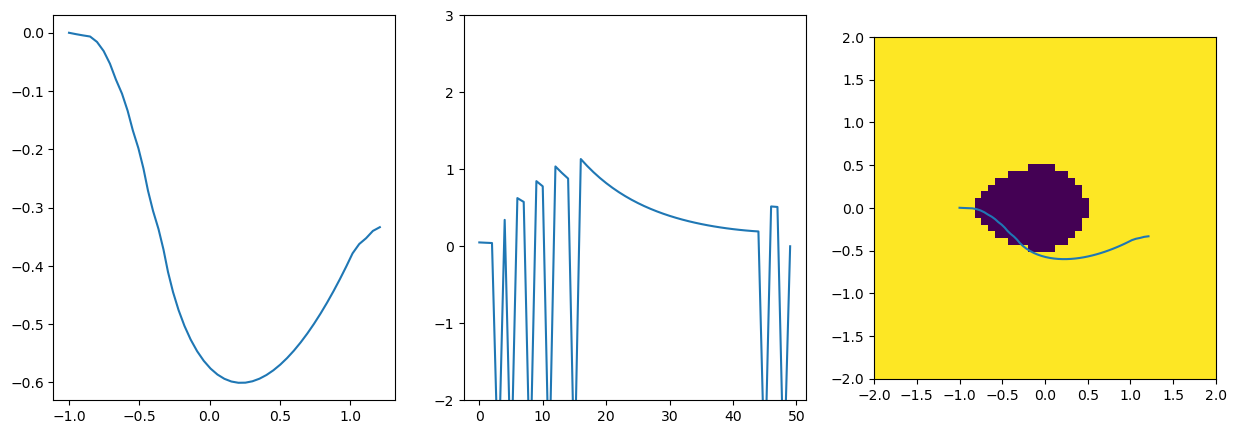

In [75]:
# Simulate with QP
# import safety_policies
# importlib.reload(safety_policies)
# from safety_policies import safety_filter, qp_filter

N = 50
dt = 0.1
actions = torch.zeros(N, 1)
values = torch.zeros(N, 1)
states = torch.zeros(N, 3)
states[0,:] = torch.tensor([-1.0, 0.0, -0.05])
u_max = 3

# Define function for gradient
# vgrad = lambda state: get_spatial_grad(value_func.V, state, eps=0.05)

eps = 0.05
dubins.speed = 0.5
goal_state = torch.tensor([1.5, 0.0, 0])
num_samples = 100
for k in range(0, N-1):
    # Nominal policy, steer towards goal
    err = dubins.state_error(goal_state, states[k, :])
    if np.linalg.norm(err[:2]) < 0.1:
        dubins.speed = 0 # Stop when we reach the goal
        actions[k, 0] = 0
    else:
        theta = np.arctan2(err[1], err[0])
        theta_err = dubins.state_error(torch.tensor([0, 0, theta]), states[k, :])[2]
        actions[k, 0] = max(-u_max, min(u_max, theta_err))

    print(value_func.state_to_V(states[k:k+1, :]))

    vfunc = value_func.state_to_V
    state = states[k:k+1, :]
    safety_V = vfunc(state)
    if safety_V <= eps:
        possible_actions = torch.linspace(-u_max, u_max, num_samples).unsqueeze(1)
        next_states = dubins.discrete_rk4(state.squeeze().repeat(num_samples, 1), possible_actions, dt)
        values = vfunc(next_states)
        distances = abs(possible_actions.squeeze() - actions[k, 0])
        # print(distances)
        # print(values)
        action_to_take = possible_actions[values > eps][torch.argmax(distances[values > eps])]
        # print(action_to_take)
        # print(distances[values > eps])
        # print(torch.argmax(distances[values > eps]))
        actions[k, 0] = action_to_take

    # Filter the policy using a QP
    # actions[k, 0], status = qp_filter(actions[k, 0], value_func.V, vgrad, states[k:k+1,:], u_max, 0.03, dubins, dt)

    # if status != 'solved': # Fall back to safety filter
    #     print("infeasible", k)
    #     actions[k, 0] = safety_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps)
    
    # actions[k, 0] = safety_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps)
    
    states[k +1:k+2, :] = dubins.discrete_rk4(states[k:k+1, :], actions[k:k+1, :], dt)

plt.figure(figsize=(15,5))
plt.subplot(1, 3, 1)
plt.plot(states[:, 0], states[:, 1])
plt.subplot(1, 3, 2)
plt.plot(actions)
plt.ylim(-2, 3)
plt.subplot(1, 3, 3)
plt.imshow(ground_truth_value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
plt.plot(states[:, 0], states[:, 1])